In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("sales.csv")
df.head()

,Month,Sales
0,1990-01-01,266.0
1,1990-02-01,145.9
2,1990-03-01,183.1
3,1990-04-01,119.3
4,1990-05-01,180.3


In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     object 
 1   Sales   36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


Month    0
Sales    0
dtype: int64

In [ ]:
df = df.dropna()
df.head()

,Month,Sales
0,1990-01-01,266.0
1,1990-02-01,145.9
2,1990-03-01,183.1
3,1990-04-01,119.3
4,1990-05-01,180.3


In [ ]:
df['Month'] = pd.to_datetime(df['Month'])

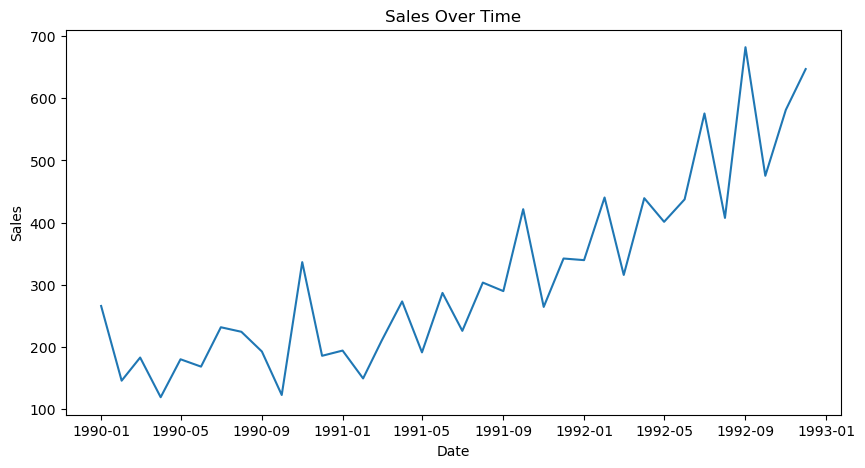

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [ ]:
df['Year'] = df['Month'].dt.year
df['Month_val'] = df['Month'].dt.month
df['Day'] = df['Month'].dt.day

In [ ]:
X = df[['Year', 'Month_val', 'Day']]
y = df['Sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)
print(predictions[:5])

[298.24642857 298.24642857 298.24642857 298.24642857 298.24642857]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 154.47589285714287
R2 Score: -0.14089542517139875
